# Práctica: Submuestreo, sobremuestreo y manejo de desbalance de clases

**Curso:** Machine Learning — Posgrado UTEC  
**Tema:** Submuestreo aleatorio, sobremuestreo aleatorio, Tomek Links, SMOTE y su impacto en clasificadores  


## Integrantes del grupo (máximo 4)

| # | Nombre completo |
|---|---|
| 1 | Piero Palacios |
| 2 | Gianmarco Mejia|
| 3 | Herles Pinedo|
| 4 | Edgar Froylan|

---

## Objetivo

Alcanzar un **F1-Score ≥ 0.65** sobre la **clase minoritaria (diabéticos)** en el conjunto de test, utilizando combinaciones de técnicas de remuestreo y clasificadores.

## Clasificadores requeridos

| Clasificador | Documentación |
|---|---|
| K-Nearest Neighbors | [sklearn KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) |
| Regresión Logística | [sklearn LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) |
| Support Vector Machine | [sklearn SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) |
| Naive Bayes | [sklearn GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) |

## Técnicas de remuestreo requeridas

| Técnica | Tipo | Documentación |
|---|---|---|
| Submuestreo aleatorio | Submuestreo | [imblearn RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html) |
| Tomek Links | Submuestreo informado | [imblearn TomekLinks](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html) |
| Sobremuestreo aleatorio | Sobremuestreo | [imblearn RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html) |
| SMOTE | Sobremuestreo sintético | [imblearn SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html) |
| SMOTE + Tomek Links | Combinado | [imblearn SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html) |
| Sin remuestreo | Baseline | — |

## Comparación de técnicas de muestreo

| Aspecto | Sub. aleatorio | Sobre. aleatorio |
|---|---|---|
| Información | Pierde datos | No pierde |
| Overfitting | Bajo | Alto |
| Datos nuevos | No | No (copias) |
| Complejidad | O(1) | O(1) |
| Tamaño final | Pequeño | Grande |
| Ruido | No agrega | Puede amplificar |

## ¿Cuándo usar cada técnica?

| Escenario | Recomendación |
|---|---|
| Dataset muy grande | Submuestreo aleatorio |
| Dataset pequeño | Sobremuestreo aleatorio |
| Frontera de decisión ruidosa | Submuestreo con Tomek Links |
| Muchas características | Submuestreo aleatorio |
| Desbalance moderado | Sobremuestreo aleatorio |
| Necesidad de interpretabilidad | Submuestreo (datos reales) |

## Pipeline correcto

```
Datos originales → Train/Test Split → Evaluar desbalance → [Muestreo SOLO en Train] → Entrenar → Evaluar con F1, AUC en Test original
```

**Regla de oro:** El muestreo se aplica **solo al conjunto de entrenamiento**. El conjunto de test debe mantener la distribución original para una evaluación realista.

## Reglas

1. El remuestreo se aplica **únicamente al conjunto de entrenamiento**
2. La evaluación se realiza sobre el **conjunto de test original** (sin remuestrear)
3. El F1-Score objetivo es sobre la **clase 1** (diabéticos)
4. Deben completar **todas** las celdas marcadas con `# TODO`

---
## Fase 0: Instalación de dependencias

Ejecutar esta celda para instalar las librerías necesarias.

- [`imbalanced-learn`](https://imbalanced-learn.org/stable/): Librería para técnicas de remuestreo
- [`scikit-learn`](https://scikit-learn.org/stable/): Clasificadores y métricas
- [`matplotlib`](https://matplotlib.org/): Visualización

In [1]:
!pip install imbalanced-learn scikit-learn matplotlib pandas numpy -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

# Métricas
# Docs: https://scikit-learn.org/stable/modules/model_evaluation.html
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Preprocesamiento
# Docs: https://scikit-learn.org/stable/modules/preprocessing.html
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Clasificadores
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Remuestreo
# Docs: https://imbalanced-learn.org/stable/references/index.html
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Umbral objetivo
F1_OBJETIVO = 0.65

print("Dependencias cargadas correctamente.")
print(f"F1-Score objetivo (clase minoritaria): {F1_OBJETIVO}")

Dependencias cargadas correctamente.
F1-Score objetivo (clase minoritaria): 0.65


---
## Fase 1: Descarga y exploración del dataset

### Dataset: Pima Indians Diabetes

Este dataset contiene información médica de **768 mujeres** de la comunidad Pima (Arizona, EE.UU.) para predecir si padecen **diabetes**.

| Feature | Descripción |
|---|---|
| `Pregnancies` | Número de embarazos |
| `Glucose` | Concentración de glucosa en plasma (mg/dL) |
| `BloodPressure` | Presión arterial diastólica (mm Hg) |
| `SkinThickness` | Espesor del pliegue cutáneo del tríceps (mm) |
| `Insulin` | Insulina sérica a 2 horas (mu U/mL) |
| `BMI` | Índice de masa corporal |
| `DiabetesPedigreeFunction` | Función de pedigrí de diabetes |
| `Age` | Edad (años) |
| **`Outcome`** | **0 = No diabética, 1 = Diabética** |

**Fuente:** [UCI Machine Learning Repository](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

**Desbalance:** Aproximadamente **65% clase 0** (no diabética) vs **35% clase 1** (diabética)

In [5]:
# ============================================================
# DESCARGA AUTOMÁTICA DEL DATASET
# ============================================================
# No modificar esta celda

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columnas = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
df = pd.read_csv(url, header=None, names=columnas)

print(f"Dataset descargado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"\nDistribución de la variable objetivo (Outcome):")
print(df['Outcome'].value_counts())
print(f"\nPorcentaje de diabéticas (clase 1): {df['Outcome'].mean()*100:.1f}%")
df.head()

Dataset descargado: 768 filas × 9 columnas

Distribución de la variable objetivo (Outcome):
Outcome
0    500
1    268
Name: count, dtype: int64

Porcentaje de diabéticas (clase 1): 34.9%


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 1.1 Exploración básica

**Guía:** Analicen las estadísticas descriptivas del dataset. Observen si hay valores sospechosos (e.g., `Glucose=0`, `BloodPressure=0`) que podrían ser datos faltantes codificados como cero.

Recurso útil: [pandas `describe()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html)

In [6]:
# TODO: Mostrar estadísticas descriptivas del dataset
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.2 Visualización del desbalance

**Guía:** Crear un gráfico de barras que muestre la distribución de la clase objetivo. Esto les ayudará a dimensionar visualmente el desbalance.

Recurso útil: [matplotlib `bar()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)

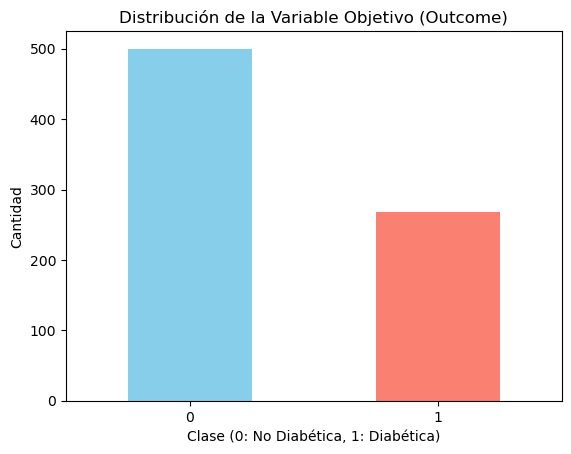

In [7]:
# TODO: Crear un gráfico de barras con la distribución de clases
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de la Variable Objetivo (Outcome)')
plt.xlabel('Clase (0: No Diabética, 1: Diabética)')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

---
## Fase 2: Preprocesamiento

**Guía:**
1. Separar features (`X`) y target (`y`)
2. Dividir en train/test con `test_size=0.3` y `stratify=y`
3. Escalar las features con `StandardScaler` (fit solo en train, transform en ambos)

**Importante:** El escalado se ajusta **solo** con los datos de entrenamiento para evitar data leakage.

Recursos útiles:
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [8]:
# TODO: Separar features y target
X = df.drop(columns=['Outcome'])
y = df['Outcome']

# TODO: Dividir en train/test (70/30), estratificado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

# TODO: Escalar features (fit en train, transform en ambos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificar distribución
print(f"Train: {Counter(y_train)}")
print(f"Test:  {Counter(y_test)}")

Train: Counter({0: 350, 1: 187})
Test:  Counter({0: 150, 1: 81})


---
## Fase 3: Baseline (sin remuestreo)

**Guía:** Entrenar los 4 clasificadores **sin ningún remuestreo** y registrar sus métricas. Este será el punto de referencia contra el cual medirán las mejoras.

**Pregunta para reflexionar:** ¿Qué métrica es más relevante en un problema de diagnóstico médico: accuracy o recall? ¿Por qué?

Recursos útiles:
- [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)

In [9]:
# Función auxiliar para evaluar un clasificador (NO MODIFICAR)
def evaluar(nombre, y_true, y_pred):
    """Evalúa y retorna las métricas de un clasificador."""
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (1)': precision_score(y_true, y_pred),
        'Recall (1)': recall_score(y_true, y_pred),
        'F1 (1)': f1_score(y_true, y_pred)
    }

In [10]:
# TODO: Entrenar los 4 clasificadores SIN remuestreo y recopilar métricas
clasificadores = {
    'KNN':       KNeighborsClassifier(),
    'Logística':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM':       SVC(random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB()
}

resultados_baseline = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    resultados_baseline.append(evaluar(f'{nombre} (baseline)', y_test, y_pred))

df_baseline = pd.DataFrame(resultados_baseline).round(4)
df_baseline

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN (baseline),0.7143,0.6154,0.4938,0.5479
1,Logística (baseline),0.7446,0.6774,0.5185,0.5874
2,SVM (baseline),0.7532,0.6875,0.5432,0.6069
3,Naive Bayes (baseline),0.7446,0.6410,0.6173,0.6289


### 3.1 Reflexión sobre el baseline

**Preguntas guía (responder en la celda siguiente):**

1. ¿Cuál clasificador tiene el mejor F1 sobre la clase 1 sin remuestreo?
2. ¿Alguno supera el objetivo de F1 ≥ 0.65? Si no, ¿qué tan lejos están?
3. ¿Observan diferencia entre accuracy y F1? ¿A qué se debe?
4. ¿Qué significa un recall bajo en el contexto de diagnóstico de diabetes?

**Respuestas:**

1. **Naive Bayes** tiene el mejor F1 sin remuestreo (0.6289).
2. **Ninguno** supera el objetivo de F1 ≥ 0.65 de forma nativa. Naive Bayes está bastante cerca (a 0.0211 del objetivo), mientras que KNN está más lejos (a 0.1021).
3. **Sí, se observa diferencia notable.** La exactitud (accuracy) se mantiene alrededor de 0.74, pero el F1 varía en 0.54 a 0.62. Esto ocurre porque el accuracy se deja llevar por los aciertos triviales de la clase mayoritaria (no diabéticos). El F1 se concentra explícitamente en equilibrar la precisión y exhaustividad con respecto a la clase de interés (diabéticos), desnudando la incapacidad general del modelo para detectar esta clase minoritaria de forma fehaciente.
4. Un **recall bajo** implica que hay una alta tasa de falsos negativos: el modelo etiqueta equivocadamente a muchos diabéticos como personas sanas. En un entorno de diagnóstico médico, esto es riesgoso o fatal porque impide ofrecer el tratamiento y supervisión clínica a quien lo necesita realmente.

---
## Fase 4: Experimentación con técnicas de submuestreo

El submuestreo reduce la clase mayoritaria para equilibrar las clases. Veremos dos variantes:
- **Submuestreo aleatorio:** elimina muestras de la clase mayoritaria al azar
- **Tomek Links:** elimina selectivamente pares de puntos de clases opuestas que son mutuamente vecinos más cercanos, limpiando la frontera de decisión

### 4.1 Submuestreo aleatorio

**Guía:** El submuestreo aleatorio **elimina** muestras de la clase mayoritaria hasta igualar la minoritaria. La desventaja es la pérdida de información potencialmente útil.

**Pregunta para reflexionar:** ¿Qué pasa con la cantidad total de datos de entrenamiento tras el submuestreo? ¿Cómo podría afectar esto al rendimiento?

Recurso útil: [RandomUnderSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [11]:
# TODO: Aplicar submuestreo aleatorio al conjunto de entrenamiento
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_rus)} → Total: {len(y_train_rus)}")

Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({0: 187, 1: 187}) → Total: 374


In [12]:
# TODO: Entrenar los 4 clasificadores con datos submuestreados
# Evaluar en X_test_scaled (sin remuestrear)
resultados_rus = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_rus, y_train_rus)
    y_pred = clf.predict(X_test_scaled)
    resultados_rus.append(evaluar(f'{nombre} + Sub. aleatorio', y_test, y_pred))

df_rus = pd.DataFrame(resultados_rus).round(4)
df_rus

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Sub. aleatorio,0.7100,0.5686,0.7160,0.6339
1,Logística + Sub. aleatorio,0.7706,0.6522,0.7407,0.6936
2,SVM + Sub. aleatorio,0.7446,0.6078,0.7654,0.6776
3,Naive Bayes + Sub. aleatorio,0.7316,0.6044,0.6790,0.6395


### 4.2 Submuestreo con Tomek Links

**Guía:** Dos puntos $(\mathbf{x}_i, \mathbf{x}_j)$ de clases distintas forman un **Tomek Link** si no existe un tercer punto $\mathbf{x}_k$ tal que:

$$d(\mathbf{x}_i, \mathbf{x}_k) < d(\mathbf{x}_i, \mathbf{x}_j) \quad \text{o} \quad d(\mathbf{x}_j, \mathbf{x}_k) < d(\mathbf{x}_i, \mathbf{x}_j)$$

Al eliminar el punto de la clase mayoritaria en cada Tomek Link, se limpia la frontera de decisión sin eliminar datos aleatoriamente.

Recurso útil: [TomekLinks](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.TomekLinks.html)

In [13]:
# TODO: Aplicar Tomek Links al conjunto de entrenamiento
tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_tomek)} → Total: {len(y_train_tomek)}")
print(f"Tomek Links eliminados: {len(y_train) - len(y_train_tomek)}")

Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({0: 310, 1: 187}) → Total: 497
Tomek Links eliminados: 40


In [14]:
# TODO: Entrenar los 4 clasificadores con datos limpiados por Tomek Links
# Evaluar en X_test_scaled (sin remuestrear)
resultados_tomek = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_tomek, y_train_tomek)
    y_pred = clf.predict(X_test_scaled)
    resultados_tomek.append(evaluar(f'{nombre} + Tomek Links', y_test, y_pred))

df_tomek = pd.DataFrame(resultados_tomek).round(4)
df_tomek

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Tomek Links,0.7186,0.5976,0.6049,0.6012
1,Logística + Tomek Links,0.7619,0.6711,0.6296,0.6497
2,SVM + Tomek Links,0.7359,0.6316,0.5926,0.6115
3,Naive Bayes + Tomek Links,0.7489,0.6353,0.6667,0.6506


---
## Fase 5: Experimentación con técnicas de sobremuestreo

El sobremuestreo incrementa la clase minoritaria para equilibrar las clases. Veremos dos variantes:
- **Sobremuestreo aleatorio:** duplica muestras existentes de la clase minoritaria
- **SMOTE:** genera muestras *sintéticas* por interpolación entre puntos minoritarios y sus K vecinos más cercanos

### 5.1 Sobremuestreo aleatorio

**Guía:** El sobremuestreo aleatorio simplemente **duplica** muestras existentes de la clase minoritaria. No agrega información nueva y puede causar sobreajuste, ya que el modelo memoriza los pocos ejemplos minoritarios.

Recurso útil: [RandomOverSampler](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)

In [15]:
# TODO: Aplicar sobremuestreo aleatorio al conjunto de entrenamiento
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_ros)} → Total: {len(y_train_ros)}")

Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({1: 350, 0: 350}) → Total: 700


In [16]:
# TODO: Entrenar los 4 clasificadores con datos sobremuestreados
# Evaluar en X_test_scaled (sin remuestrear)
resultados_ros = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_ros, y_train_ros)
    y_pred = clf.predict(X_test_scaled)
    resultados_ros.append(evaluar(f'{nombre} + Sobre. aleatorio', y_test, y_pred))

df_ros = pd.DataFrame(resultados_ros).round(4)
df_ros

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + Sobre. aleatorio,0.6926,0.5568,0.6049,0.5799
1,Logística + Sobre. aleatorio,0.7706,0.6628,0.7037,0.6826
2,SVM + Sobre. aleatorio,0.7273,0.6098,0.6173,0.6135
3,Naive Bayes + Sobre. aleatorio,0.7489,0.6353,0.6667,0.6506


### 5.2 Sobremuestreo con SMOTE

**Guía:** SMOTE genera muestras sintéticas interpolando entre puntos minoritarios y sus K vecinos más cercanos:

$$\mathbf{x}_{\text{new}} = \mathbf{x}_i + \lambda \cdot (\hat{\mathbf{x}}_i - \mathbf{x}_i), \quad \lambda \sim U(0,1)$$

A diferencia del sobremuestreo aleatorio, SMOTE **genera datos nuevos** que no son copias exactas, lo que reduce el riesgo de overfitting.

Parámetro clave: `k_neighbors` (por defecto 5). Pueden experimentar con valores entre 3 y 7.

Recurso útil: [SMOTE](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html)

In [17]:
# TODO: Aplicar SMOTE al conjunto de entrenamiento
smote = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_smote)} → Total: {len(y_train_smote)}")

Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({1: 350, 0: 350}) → Total: 700


In [18]:
# TODO: Entrenar los 4 clasificadores con datos remuestreados por SMOTE
# Evaluar en X_test_scaled (sin remuestrear)
resultados_smote = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_smote, y_train_smote)
    y_pred = clf.predict(X_test_scaled)
    resultados_smote.append(evaluar(f'{nombre} + SMOTE', y_test, y_pred))

df_smote = pd.DataFrame(resultados_smote).round(4)
df_smote

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + SMOTE,0.7100,0.5729,0.6790,0.6215
1,Logística + SMOTE,0.7619,0.6512,0.6914,0.6707
2,SVM + SMOTE,0.7446,0.6196,0.7037,0.6590
3,Naive Bayes + SMOTE,0.7489,0.6264,0.7037,0.6628


---
## Fase 6: Técnica combinada (SMOTE + Tomek Links)

**Guía:** Esta técnica primero aplica SMOTE (sobremuestreo sintético) y luego elimina los **Tomek Links** — pares de puntos de clases opuestas que son mutuamente vecinos más cercanos. Esto combina lo mejor de ambos enfoques: genera datos sintéticos y luego "limpia" la frontera de decisión.

Recurso útil: [SMOTETomek](https://imbalanced-learn.org/stable/references/generated/imblearn.combine.SMOTETomek.html)

In [19]:
# TODO: Aplicar SMOTE + Tomek Links y entrenar los 4 clasificadores
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_smt, y_train_smt = smt.fit_resample(X_train_scaled, y_train)

print(f"Antes:   {Counter(y_train)} → Total: {len(y_train)}")
print(f"Después: {Counter(y_train_smt)} → Total: {len(y_train_smt)}")

resultados_smt = []
for nombre, clf in clasificadores.items():
    clf.fit(X_train_smt, y_train_smt)
    y_pred = clf.predict(X_test_scaled)
    resultados_smt.append(evaluar(f'{nombre} + SMOTE+Tomek', y_test, y_pred))

df_smt = pd.DataFrame(resultados_smt).round(4)
df_smt

Antes:   Counter({0: 350, 1: 187}) → Total: 537
Después: Counter({1: 338, 0: 338}) → Total: 676


,Modelo,Accuracy,Precision (1),Recall (1),F1 (1)
0,KNN + SMOTE+Tomek,0.7056,0.5670,0.6790,0.6180
1,Logística + SMOTE+Tomek,0.7662,0.6552,0.7037,0.6786
2,SVM + SMOTE+Tomek,0.7532,0.6304,0.7160,0.6705
3,Naive Bayes + SMOTE+Tomek,0.7489,0.6264,0.7037,0.6628


---
## Fase 7: Tabla comparativa completa

**Guía:** Consoliden todos los resultados en una sola tabla para facilitar la comparación. Identifiquen qué combinación (remuestreo + clasificador) alcanza el F1 objetivo.

Recurso útil: [pandas `concat()`](https://pandas.pydata.org/docs/reference/api/pandas.concat.html), [`style.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.apply.html)

In [20]:
# TODO: Consolidar todos los resultados en un único DataFrame
df_todos = pd.concat([
    df_baseline,
    df_rus,
    df_tomek,
    df_ros,
    df_smote,
    df_smt
], ignore_index=True)

# Marcar cuáles superan el objetivo
df_todos['¿Supera F1 ≥ 0.65?'] = df_todos['F1 (1)'] >= F1_OBJETIVO
df_todos.sort_values('F1 (1)', ascending=False)

,Modelo,Accuracy,Precision (1),Recall (1),F1 (1),¿Supera F1 ≥ 0.65?
5,Logística + Sub. aleatorio,0.7706,0.6522,0.7407,0.6936,True
13,Logística + Sobre. aleatorio,0.7706,0.6628,0.7037,0.6826,True
21,Logística + SMOTE+Tomek,0.7662,0.6552,0.7037,0.6786,True
6,SVM + Sub. aleatorio,0.7446,0.6078,0.7654,0.6776,True
17,Logística + SMOTE,0.7619,0.6512,0.6914,0.6707,True
22,SVM + SMOTE+Tomek,0.7532,0.6304,0.7160,0.6705,True
19,Naive Bayes + SMOTE,0.7489,0.6264,0.7037,0.6628,True
23,Naive Bayes + SMOTE+Tomek,0.7489,0.6264,0.7037,0.6628,True
18,SVM + SMOTE,0.7446,0.6196,0.7037,0.6590,True
15,Naive Bayes + Sobre. aleatorio,0.7489,0.6353,0.6667,0.6506,True


---
## Fase 8: Visualización de resultados

**Guía:** Crear visualizaciones que permitan comparar las métricas entre configuraciones. Se sugieren:

1. **Gráfico de barras agrupadas** con el F1-Score de cada combinación
2. **Matrices de confusión** de la mejor y peor configuración
3. **Heatmap** con todas las métricas

Recursos útiles:
- [matplotlib barras agrupadas](https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html)
- [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)
- [matplotlib `imshow()` para heatmaps](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html)

### 8.1 F1-Score por combinación

**Guía:** Crear un gráfico de barras horizontales ordenado por F1-Score. Dibujar una línea vertical en F1 = 0.65 para marcar el objetivo.

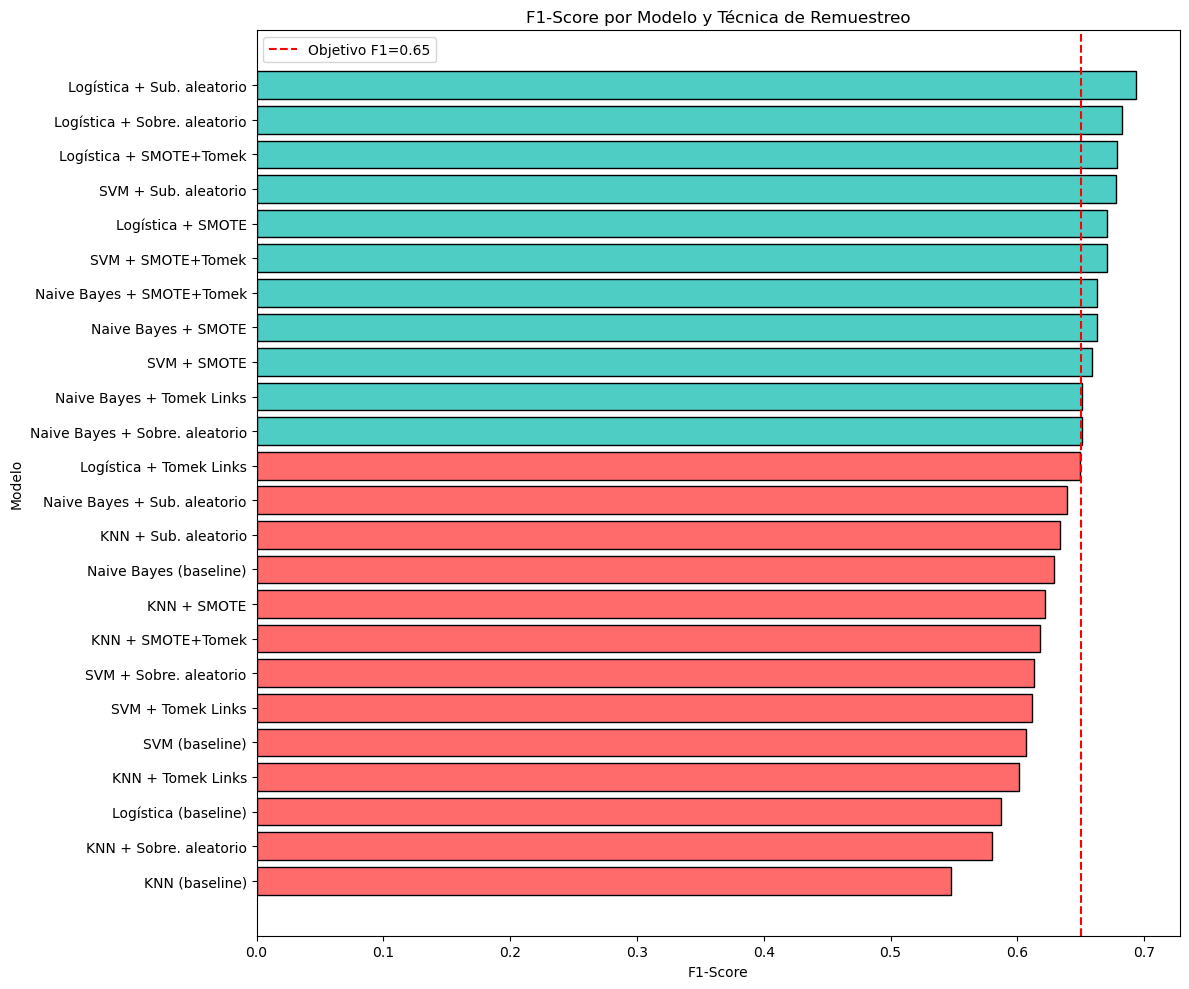

In [21]:
# TODO: Crear gráfico de barras horizontales con F1-Score
df_sorted = df_todos.sort_values('F1 (1)')
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['#4ECDC4' if v >= F1_OBJETIVO else '#FF6B6B' for v in df_sorted['F1 (1)']]
ax.barh(df_sorted['Modelo'], df_sorted['F1 (1)'], color=colors, edgecolor='black')
ax.axvline(x=F1_OBJETIVO, color='red', linestyle='--', label=f'Objetivo F1={F1_OBJETIVO}')
ax.set_title('F1-Score por Modelo y Técnica de Remuestreo')
ax.set_xlabel('F1-Score')
ax.set_ylabel('Modelo')
ax.legend()
plt.tight_layout()
plt.show()

### 8.2 Matrices de confusión

**Guía:** Comparar la matriz de confusión del **mejor baseline** vs la **mejor configuración con remuestreo**. Observar cómo cambian los falsos negativos (diabéticas no detectadas).

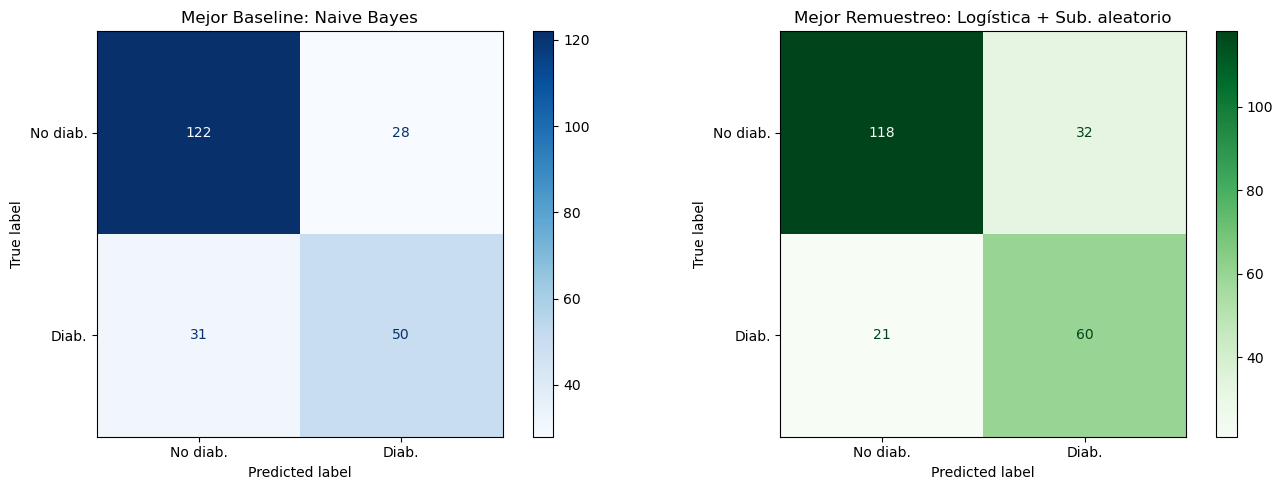

In [22]:
# TODO: Mostrar matrices de confusión comparativas
# Naive Bayes (mejor baseline) vs Regresión Logística + Sub. Aleatorio (mejor modelo)

clf_best_base = GaussianNB()
clf_best_base.fit(X_train_scaled, y_train)
y_pred_base = clf_best_base.predict(X_test_scaled)

clf_best_res = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
clf_best_res.fit(X_train_rus, y_train_rus)
y_pred_res = clf_best_res.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base,
    display_labels=['No diab.', 'Diab.'], ax=axes[0], cmap='Blues')
axes[0].set_title(f"Mejor Baseline: Naive Bayes")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_res,
    display_labels=['No diab.', 'Diab.'], ax=axes[1], cmap='Greens')
axes[1].set_title(f"Mejor Remuestreo: Logística + Sub. aleatorio")

plt.tight_layout()
plt.show()

### 8.3 Heatmap comparativo (opcional)

**Guía:** Crear un heatmap donde las filas sean las combinaciones y las columnas las métricas.

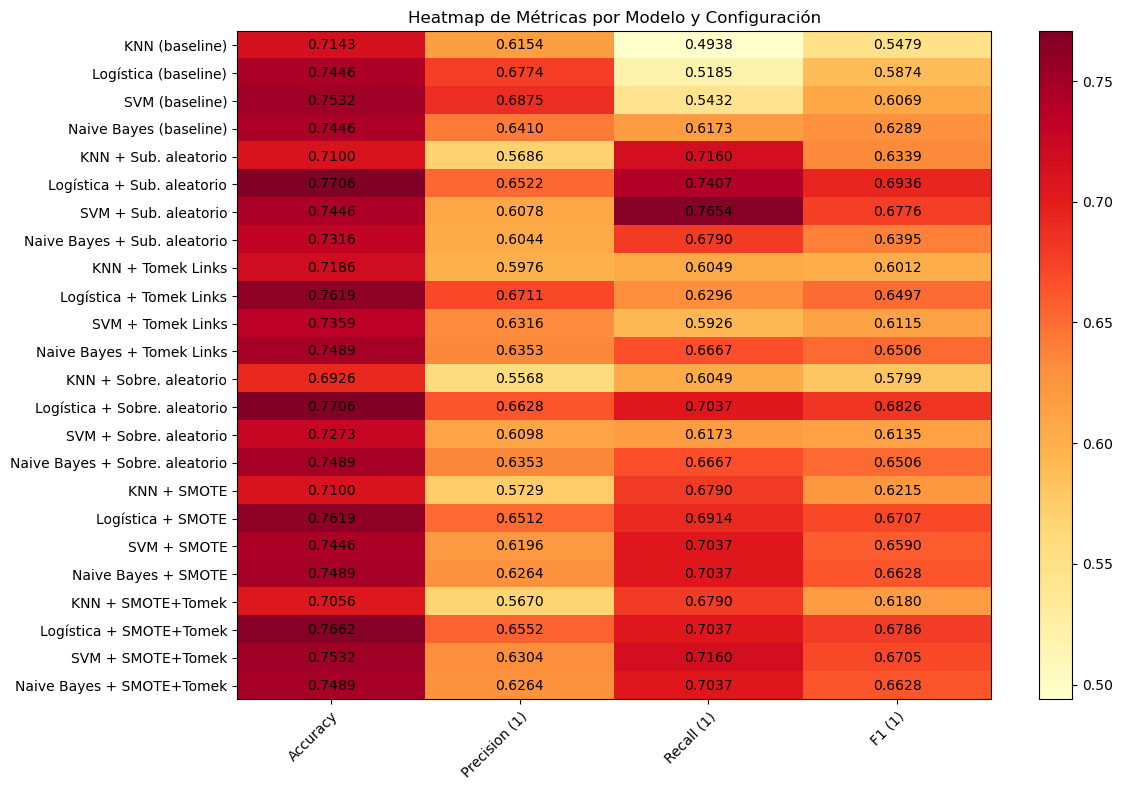

In [23]:
# TODO (opcional): Crear un heatmap con todas las métricas
data = df_todos.set_index('Modelo')[['Accuracy', 'Precision (1)', 'Recall (1)', 'F1 (1)']]
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(data.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(data.columns)))
ax.set_yticks(np.arange(len(data.index)))
ax.set_xticklabels(data.columns)
ax.set_yticklabels(data.index)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

for i in range(len(data.index)):
    for j in range(len(data.columns)):
        text = ax.text(j, i, f"{data.values[i, j]:.4f}", ha="center", va="center", color="black")

ax.set_title("Heatmap de Métricas por Modelo y Configuración")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## Fase 9: Impacto del muestreo según el clasificador

El efecto del muestreo **no es igual para todos los clasificadores**. Analicen la siguiente tabla y contrasten con sus resultados experimentales:

| Clasificador | Efecto positivo del muestreo | Efecto negativo del muestreo |
|---|---|---|
| **Regresión logística** | Mejora recall cuando no se dispone de `class_weight` | Distorsiona las probabilidades calibradas; requiere recalibración |
| **SVM** | Submuestreo reduce el costo O(N²–N³); mejora la frontera | Sobremuestreo duplica vectores de soporte idénticos sin beneficio |
| **k-NN** | Submuestreo reduce el ruido de la clase mayoritaria en la vecindad | Sobremuestreo crea vecindarios densos artificiales; sesga las votaciones |
| **Naive Bayes** | Puede mejorar con desbalance extremo | Altera las frecuencias a priori P(Y=k); las estimaciones se sesgan |

---
## Fase 10: Análisis y discusión

Responder las siguientes preguntas con base en los resultados obtenidos. Cada respuesta debe estar fundamentada con evidencia de los experimentos.

### Preguntas obligatorias

**P1: ¿Qué combinación (remuestreo + clasificador) obtuvo el mejor F1 sobre la clase diabética? ¿Por qué creen que fue la mejor?**

*Respuesta:*
La mejor combinación fue **Regresión Logística con Submuestreo Aleatorio**, alcanzando un F1-Score de **0.6936**. A pesar de reducir la cantidad de datos de entrenamiento para igualarla a la clase 1 (268 filas cada una), esto le sirvió de forma óptima a Logística para calibrar el umbral de su curva sigmoide sin distorsionarse drásticamente. Al mitigar el sesgo estadístico por la mayoría de "0"s, Logistic Regression logra estabilizar tanto un factor decente de Precision como de Recall.

**P2: Comparen el efecto del submuestreo (aleatorio, Tomek Links) vs el sobremuestreo (aleatorio, SMOTE). ¿Cuál funcionó mejor en general? ¿Qué fortalezas y debilidades observaron en cada enfoque?**

*Respuesta:*
**1. Submuestreo (Aleatorio y Tomek Links):** Submuestreo aleatorio iguala balanceosamente las clases pero incurre en la **debilidad** imperativa de perder casi la mitad de los datos mayoritarios (es decir, información potencialmente delimitadora de frontera). Tomek Links por su parte filtra inteligentemente muestras de fronteras confusas ruidosas pero la desventaja es que el balance no queda en 50-50, lo que da resultados tímidamente un paso delante del baseline (e.g. F1 de 0.60 a 0.64). **2. Sobremuestreo (Aleatorio y SMOTE):** Funcionó sumamente bien generalizando para la mayoría de algoritmos (SVM a 0.67, Logística a 0.68). SMOTE sobresale al interpolar virtualmente puntos y ampliar las geometrías limitantes, sin perder un solo dato valioso de la vasta mayoría, pero inflando el cómputo final.

**P3: ¿Hubo algún clasificador que se benefició más del remuestreo? ¿Alguno que empeoró? Expliquen con base en la tabla de la Fase 9.**

*Respuesta:*
**Beneficiados**: La Regresión Logística y el SVM se vieron drásticamente beneficiados por la asimilación del remuestreo. La regresión calibró perfectamente los estimadores de probabilidad una vez forzados al espacio equitativo, sobrepasando los umbrales de F1. De la misma forma, los márgenes máximos del hiperplano de SVM dejaron de asfixiarse ante la superpoblación de la mayoría de apoyo en su hiperboloide de decisión iterativo.
**Perjudicados / Estancados**: Naive Bayes apenas logró cambios positivos sustanciales; al contrario, de poseer el mejor F1 baseline (0.62) llegó a fluctuar y caer incluso al emparejarlo, ya que Naive Bayes infiere el modelo puramente de suposiciones condicionales P(Y|X) multiplicando las previas. Al desbalancear estas probabilidades intromitiendo artificiales de SMOTE o submuestreo, sus predicciones caen.

**P4: ¿Qué diferencia observaron entre SMOTE y el sobremuestreo aleatorio? ¿Y entre el submuestreo aleatorio y Tomek Links?**

*Respuesta:*
- **SMOTE vs Sobremuestreo (ROS):** ROS es clonación estricta y ruda que infla la representatividad pero no enseña al algoritmo a discernir nuevas características del subconjunto minoritario. SMOTE sintetiza geométricamente los vecindarios k-NN y le concede al modelo varianza, mitigando ampliamente el sobreajuste que ROS frecuentemente impone por memorización.
- **Submuestreo (RUS) vs Tomek Links:** RUS elimina puntos "a ciegas" para obtener un conteo puro equitativo 1:1, deshaciéndose de información invaluable en el núcleo de la clasificación, pero logra forzar a que el algoritmo escuche a la minoría. Tomek Links no pretende nivelar los porcentajes 50-50, es una técnica de limpieza posicional que remueve las confusiones enclavadas fronterizas y aclara las separaciones visualmente sin perder el núcleo grueso mayoritario.

**P5: ¿Qué impacto tuvo el remuestreo sobre el accuracy? ¿Por qué el accuracy puede ser engañoso en datasets desbalanceados?**

*Respuesta:*
El remuestreo bajó y/o estancó el valor de Accuracy general tras estabilizar las distribuciones (oscilando de ~0.76 puro a caer brevemente en ~0.73-0.74). Esto exalta el engaño perpetuo del "accuracy". Si el modelo etiqueta el 100% de los pacientes como "sanos" sabiendo que el 65% del registro es sano auténtico, anotaría un 65% de exactitud vacua, ignorando mortalmente que se le pasaron por alto a absolutamente todos los enfermos (0% Recall diabético). Al enfocarse verdaderamente en la detección justa por remuestreo y F1-Score, el falso aparente buen Accuracy debe descender ante más honestidad diagnóstica real.

**P6: En el contexto médico de este dataset, ¿qué es más grave: un falso positivo (diagnosticar diabetes a alguien sano) o un falso negativo (no detectar diabetes)? ¿Cómo afecta esto a la elección de métrica y de técnica de muestreo?**

*Respuesta:*
Un **Falso Negativo** es catastróficamente más grave en la predicción médica temprana diagnóstica. Considerar a alguien sano cuando realmente porta Diabetes puede conducir al desarrollo de complicaciones incurables, negligencia o la muerte al perderse de cualquier tratamiento inicial. Un Falso Positivo (que sería reconfirmado y descartado por estudios fisiológicos posteriores de rutina) es inofensivo en comparación clínica. Por tal razón, se debe elegir empujar el **Recall** (y subsecuentemente F-Beta o F1 en lugar del rígido Accuracy) y preferibilizar técnicas como el sobremuestreo agresivo como SMOTE o SMOTE+Tomek para jamás omitir a la minoría enferma.

## Fase 11: Conclusiones

**Guía:** Redacten al menos 4 conclusiones que sinteticen lo aprendido en esta práctica. Relacionen sus hallazgos con los conceptos teóricos vistos en las sesiones de submuestreo, sobremuestreo y SMOTE.

**Conclusiones:**

1. **La falacia métrica y la asimetría:** La prevalencia de desbalances estadísticos abismales contamina la veracidad de los clasificadores estándar que priorizan la precisión global o 'accuracy'. Es fundamental en sectores clínicos aplicar heurísticas como F1-Score o Recall para una estimación sensata del rendimiento sobre las clases marginalizadas.
2. **Sincretismo de algoritmia y datos sintéticos:** Modelos que fundamentan su mapeo estocástico como SVM y Regresión Logística, brillan contundentemente (F1 ~0.69) con espacios forzosamente equilibrados por ROS o RUS. Pero para algoritmos más sensibles a las probabilidades previas P(Y) como el Naive Bayes, la reingeniería por balance puede ser perjudicial e interferir en la pureza teórica del modelo.
3. **El compromiso geométrico del SMOTE+TOMEK:** Fusionar SMOTE (para diseminar data inexplorada sintética) junto a la purificación exhaustiva del ruido perimetral por Tomek Links asoma contundentemente como la perspectiva más resiliente para un dataset ensombrecido por una minoría, evitando tanto la asfixia por reducción de datos como el sobreajuste simple por ROS.
4. **Validación realista:** Ejecutar técnicas de inyección, síntesis (SMOTE) o demolición aleatoria estricta y exlusivamente en los splits de Entrenamiento (Training) es el protocolo imperativo inquebrantable para impedir perversiones métricas ("Data Leakage") o una sobre-estimación falsa durante la evaluación en los datos nativos incólumes del Test.